<a href="https://colab.research.google.com/github/Manish927/EDA-Data-Science/blob/main/ML-Models/Decision-Tree/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Tree Model for Binary Classification

Problem: Is to identify product at risk of backorder before the event occurs so the business has time to react.


## Data
Data file contains the historical data for the 8 weeks prior to the week we are trying to predict. The data was taken as weekly snapshots at the start of each week. Columns are defined as follows:

sku - Random ID for the product

national_inv - Current inventory level for the part

lead_time - Transit time for product (if available)

in_transit_qty - Amount of product in transit from source

forecast_3_month - Forecast sales for the next 3 months

forecast_6_month - Forecast sales for the next 6 months

forecast_9_month - Forecast sales for the next 9 months

sales_1_month - Sales quantity for the prior 1 month time period

sales_3_month - Sales quantity for the prior 3 month time period

sales_6_month - Sales quantity for the prior 6 month time period

sales_9_month - Sales quantity for the prior 9 month time period

min_bank - Minimum recommend amount to stock

potential_issue - Source issue for part identified

pieces_past_due - Parts overdue from source

perf_6_month_avg - Source performance for prior 6 month period

perf_12_month_avg - Source performance for prior 12 month period

local_bo_qty - Amount of stock orders overdue

deck_risk - Part risk flag

oe_constraint - Part risk flag

ppap_risk - Part risk flag

stop_auto_buy - Part risk flag

rev_stop - Part risk flag

went_on_backorder - Product actually went on backorder. This is the target value.

     Yes or 1 : Product backordered

     No or 0  : Product not backordered

In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
import itertools
from sklearn import tree

import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
# Loading the data
URL = 'https://raw.githubusercontent.com/Manish927/EDA-Data-Science/refs/heads/main/ML-Models/Decision-Tree/backorders.csv'
df_backorder = pd.read_csv(URL)
df_backorder.

(61589, 23)

In [ ]:
df_backorder.head()

In [8]:
# to supress scientific notations
pd.options.display.float_format = '{:.2f}'.format


In [9]:
df_backorder.describe()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty
count,61589.00,61589.00,58186.00,61589.00,61589.00,61589.00,61589.00,61589.00,61589.00,61589.00,61589.00,61589.00,61589.00,61589.00,61589.00,61589.00
mean,2037187.68,287.72,7.56,30.19,169.27,315.04,453.58,44.74,150.73,283.55,419.64,43.09,1.61,-6.26,-5.86,1.21
std,656417.82,4233.91,6.50,792.87,5286.74,9774.36,14202.01,1373.81,5224.96,8872.27,12698.58,959.61,42.31,25.54,24.84,29.98
min,1068628.00,-2999.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-99.00,-99.00,0.00
25%,1498574.00,3.00,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.62,0.64,0.00
50%,1898033.00,10.00,8.00,0.00,0.00,0.00,0.00,0.00,2.00,4.00,6.00,0.00,0.00,0.82,0.80,0.00
75%,2314826.00,57.00,8.00,0.00,12.00,25.00,36.00,6.00,17.00,34.00,51.00,3.00,0.00,0.96,0.95,0.00
max,3284895.00,673445.00,52.00,170976.00,1126656.00,2094336.00,3062016.00,295197.00,934593.00,1799099.00,2631590.00,192978.00,7392.00,1.00,1.00,2999.00


In [10]:
# We are dropping SKU as it will not be required for our modelling purpose
df_backorder.drop('sku', axis=1, inplace=True)

In [11]:
df_backorder.isnull().sum()

,0
national_inv,0
lead_time,3403
in_transit_qty,0
forecast_3_month,0
forecast_6_month,0
forecast_9_month,0
sales_1_month,0
sales_3_month,0
sales_6_month,0
sales_9_month,0


In [12]:
# Since the nubmer of missing values is about 5%. For initial analysis we ignore all the se records.
df_backorder.dropna(axis=0)
# removes any row from the DataFrame df_backorder that contains at least one missing value (NaN or None)

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
1,7,2.00,0,0,0,0,0,0,0,0,0,No,0,0.50,0.28,0,Yes,No,No,Yes,No,No
2,258,15.00,10,10,77,184,46,132,256,365,47,No,0,0.54,0.70,0,No,No,No,Yes,No,No
3,46,2.00,0,0,0,0,1,2,6,9,1,No,0,0.75,0.90,0,Yes,No,No,Yes,No,No
4,2,2.00,0,4,6,10,2,2,5,6,0,No,0,0.97,0.92,0,No,No,No,Yes,No,No
5,297,12.00,0,0,0,0,5,6,44,57,3,No,0,0.58,0.75,0,Yes,No,No,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61583,80,2.00,0,0,0,0,7,8,9,15,3,No,0,1.00,0.91,0,Yes,No,No,Yes,No,No
61584,6,8.00,0,24,24,24,0,7,9,12,1,No,0,0.98,0.98,0,No,No,No,Yes,No,No
61585,130,2.00,0,40,80,140,18,108,230,317,34,No,0,0.51,0.28,0,No,No,No,Yes,No,No
61586,135,9.00,0,0,0,0,10,40,65,89,2,No,0,1.00,0.99,0,No,No,Yes,Yes,No,No


In [15]:
# Dummy coding for categorical variables
non_numeric_columns = df_backorder.select_dtypes(include=['object']).columns
df_backorder = pd.get_dummies(columns=non_numeric_columns, data=df_backorder, prefix=non_numeric_columns, prefix_sep='_', drop_first=True)

In [20]:
df_backorder.dtypes

,0
national_inv,int64
lead_time,float64
in_transit_qty,int64
forecast_3_month,int64
forecast_6_month,int64
forecast_9_month,int64
sales_1_month,int64
sales_3_month,int64
sales_6_month,int64
sales_9_month,int64


In [16]:
print(df_backorder.columns, df_backorder.shape)

Index(['national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month',
       'forecast_6_month', 'forecast_9_month', 'sales_1_month',
       'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank',
       'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg',
       'local_bo_qty', 'potential_issue_Yes', 'deck_risk_Yes',
       'oe_constraint_Yes', 'ppap_risk_Yes', 'stop_auto_buy_Yes',
       'rev_stop_Yes', 'went_on_backorder_Yes'],
      dtype='object') (61589, 22)


In [21]:
# Target variable distribution
pd.value_counts(df_backorder['went_on_backorder_Yes'].values)

/tmp/ipython-input-274/4057558479.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df_backorder['went_on_backorder_Yes'].values)


,count
False,50296
True,11293


In [22]:
# Performing train test split on the data
X, Y = df_backorder.loc[:, df_backorder.columns != 'went_on_backorder_Yes'].values, df_backorder.loc[:,'went_on_backorder_Yes'].values

# Split out dataset into train and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

In [23]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(49271, 21)
(12318, 21)
(49271,)
(12318,)


In [24]:
# To get the distribution in the target in train and test
print(pd.value_counts(Y_train))
print(pd.value_counts(Y_test))

False    40247
True      9024
Name: count, dtype: int64
False    10049
True      2269
Name: count, dtype: int64


/tmp/ipython-input-274/3315184211.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(Y_train))
/tmp/ipython-input-274/3315184211.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print(pd.value_counts(Y_test))


In [25]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    #if normalize:
     #   cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
     #  print("Normalized confusion matrix")
    #else:
    #    print('Confusion matrix, without normalization')

    #print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

In [26]:
# Create an instance of DecisionTreeClassifier()
classifier = tree.DecisionTreeClassifier(random_state=1)

# Fit our model to the data
model_DT_Gini = classifier.fit(X_train, Y_train)
model_DT_Gini

DecisionTreeClassifier(random_state=1)

In [27]:
# Predict with our test data
test_predictedvalues = model_DT_Gini.predict(X_test)

In [28]:
# Check accuracy
acc = accuracy_score(Y_test, test_predictedvalues)
print("Accuracy is", acc)

# Check TP, TN, FP, FN
tn, fp, fn, tp = confusion_matrix(Y_test, test_predictedvalues).ravel()
print("TN:",tn, " FP:",fp, " FN:",fn, " TP:",tp)

Accuracy is 0.9124046111381717
TN: 9480  FP: 569  FN: 510  TP: 1759


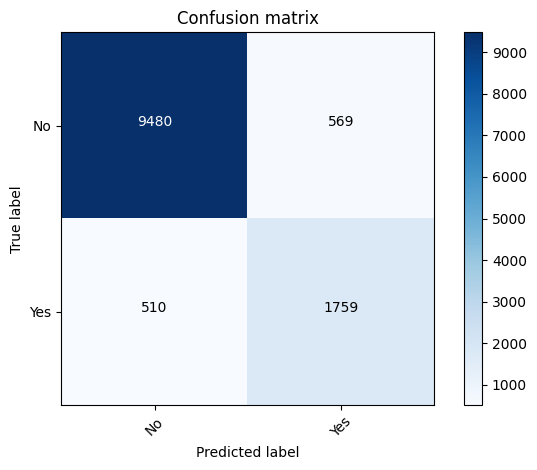

In [29]:
target_names = [ 'No', 'Yes']

#Pass Actual & Predicted values to confusion_matrix()
cm = confusion_matrix(Y_test, test_predictedvalues)

plt.figure()
plot_confusion_matrix(cm, classes=target_names, normalize=False)
plt.show()

# Changing Hyper-Parameters
Grid Search for hyper-parameter tuning
Parameters
criterion : string, optional (default=”gini”)

The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “entropy” for the information gain.

min_samples_split : int, float, optional (default=2)

The minimum number of samples required to split an internal node.

max_depth : int or None, optional (default=None)

The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

min_samples_leaf : int, float, optional (default=1)

The minimum number of samples required to be at a leaf node.

max_leaf_nodes : int or None, optional (default=None)

Grow a tree with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity. If None then unlimited number of leaf nodes.

In [30]:
# set the parameters for grid search
grid_search_parameters = {"criterion": ["gini", "entropy"],
              "min_samples_split": [2,3],
              "max_depth": [None, 2, 3],
              "min_samples_leaf": [1, 5],
              "max_leaf_nodes": [None],
              }

In [31]:
from sklearn.model_selection import GridSearchCV

# Create an instance of DecisionTreeClassifier()
classifier = tree.DecisionTreeClassifier()

# Use GridSearchCV(), pass the values you have set for grid search
model_DT_Grid = GridSearchCV(classifier, grid_search_parameters, cv=10)
model_DT_Grid.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 2, 3], 'max_leaf_nodes': [None],
                         'min_samples_leaf': [1, 5],
                         'min_samples_split': [2, 3]})

In [32]:
model_DT_Grid.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'max_leaf_nodes': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

Accuracy is 0.9124046111381717
TN: 9460  FP: 589  FN: 476  TP: 1793


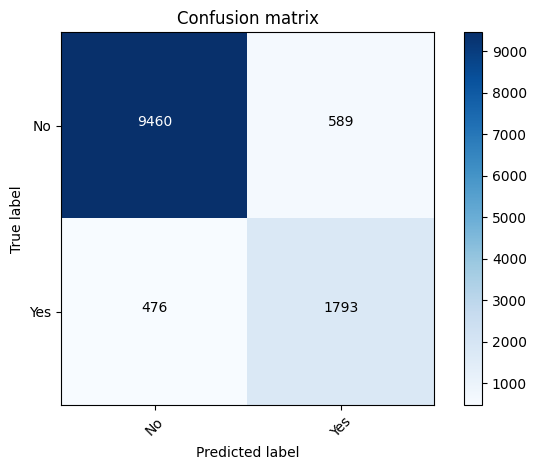

In [33]:
test_predictedvalues = model_DT_Grid.predict(X_test)

cc = accuracy_score(Y_test, test_predictedvalues)
print("Accuracy is", acc)

tn, fp, fn, tp = confusion_matrix(Y_test, test_predictedvalues).ravel()
print("TN:",tn, " FP:",fp, " FN:",fn, " TP:",tp)

cm = confusion_matrix(Y_test, test_predictedvalues)

plt.figure()
plot_confusion_matrix(cm, classes=target_names, normalize=False)
plt.show()

In [34]:
model_DT_Grid

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 2, 3], 'max_leaf_nodes': [None],
                         'min_samples_leaf': [1, 5],
                         'min_samples_split': [2, 3]})

In [35]:
from sklearn.metrics import classification_report

target_names = [ 'No', 'Yes']
print(classification_report(Y_test, test_predictedvalues, target_names=target_names))

              precision    recall  f1-score   support

          No       0.95      0.94      0.95     10049
         Yes       0.75      0.79      0.77      2269

    accuracy                           0.91     12318
   macro avg       0.85      0.87      0.86     12318
weighted avg       0.92      0.91      0.91     12318

